# **BMW Car Data Analysis**

**Introduction**

I have chosen to analyze a BMW Car dataset for this project. I will be using generative AI tools to assist me with exploratory data analysis as well as modeling. 

**About the dataset**

This dataset is from the Kaggle website and its link is: https://www.kaggle.com/datasets/guriya79/bmw-cars

The columns of the dataset along with their meaning are as follows: 
1. **model**: BMW vehicle model
2. **year**: Year of manufacture
3. **price**: Listed price of the vehicle
4. **transmission**: Type of transmission
5. **mileage**: Distance driven
6. **fuelType**: Type of fuel used
7. **tax**: Road tax amount
8. **mpg**: Fuel efficiency (miles per gallon)
9. **engineSize**: Engine size in liters

**Prepratory Stage**

In this section, I will be performing the necessary steps to prepare for EDA and modeling analysis.

In [2]:
# Loading the dataset into a pandas dataframe

import pandas as pd

path = "bmw.csv"

df = pd.read_csv(path)

df.head()

,model,year,price,transmission,mileage,fuelType,tax,mpg,engineSize
0,5 Series,2014,11200,Automatic,67068,Diesel,125,57.6,2.0
1,6 Series,2018,27000,Automatic,14827,Petrol,145,42.8,2.0
2,5 Series,2016,16000,Automatic,62794,Diesel,160,51.4,3.0
3,1 Series,2017,12750,Automatic,26676,Diesel,145,72.4,1.5
4,7 Series,2014,14500,Automatic,39554,Diesel,160,50.4,3.0


**NOTE:** This dataset has already been pre-processed and cleaned by the creator on Kaggle. However, I will still show the necessary code to preprocess and clean the dataset. 

In [9]:
# Preprocessing / Cleaning Dataset by handling missing values, standardizing columns, dropping duplicates, etc.

# import pandas as pd

# missing_columns = df.columns[df.isnull().any()]
# print(missing_columns)

# df = df.fillna(df.mean(numeric_only=True))

# df = df.dropna()

# df = df.drop_duplicates()

#from sklearn.preprocessing import StandardScaler

# scaler = StandardScaler()

# df[df.select_dtypes(include='number').columns] = scaler.fit_transform(df.select_dtypes(include='number'))

print(df.head())

       model  year  price transmission  mileage fuelType  tax   mpg  \
0   5 Series  2014  11200    Automatic    67068   Diesel  125  57.6   
1   6 Series  2018  27000    Automatic    14827   Petrol  145  42.8   
2   5 Series  2016  16000    Automatic    62794   Diesel  160  51.4   
3   1 Series  2017  12750    Automatic    26676   Diesel  145  72.4   
4   7 Series  2014  14500    Automatic    39554   Diesel  160  50.4   

   engineSize  
0         2.0  
1         2.0  
2         3.0  
3         1.5  
4         3.0  


**Exploratory Data Analysis (EDA)**

In this next section, I will be performing explatory data analysis (EDA) on the dataset. 

In [55]:
# Statistical summary of dataset
df.describe()

,year,price,mileage,tax,mpg,engineSize
count,10781.000000,10781.000000,10781.000000,10781.000000,10781.000000,10781.000000
mean,2017.078935,22733.408867,25496.986550,131.702068,56.399035,2.167767
std,2.349038,11415.528189,25143.192559,61.510755,31.336958,0.552054
min,1996.000000,1200.000000,1.000000,0.000000,5.500000,0.000000
25%,2016.000000,14950.000000,5529.000000,135.000000,45.600000,2.000000
50%,2017.000000,20462.000000,18347.000000,145.000000,53.300000,2.000000
75%,2019.000000,27940.000000,38206.000000,145.000000,62.800000,2.000000
max,2020.000000,123456.000000,214000.000000,580.000000,470.800000,6.600000


In [56]:
# Concise summary of dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10781 entries, 0 to 10780
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   model         10781 non-null  object 
 1   year          10781 non-null  int64  
 2   price         10781 non-null  int64  
 3   transmission  10781 non-null  object 
 4   mileage       10781 non-null  int64  
 5   fuelType      10781 non-null  object 
 6   tax           10781 non-null  int64  
 7   mpg           10781 non-null  float64
 8   engineSize    10781 non-null  float64
dtypes: float64(2), int64(4), object(3)
memory usage: 758.2+ KB


**Reflection:**

We can see that there are 10781 rows in the dataset. We also see the mean values for each column in df.describe() function as well as the min, quartiles, and max of each column. Lastly, we also see that there are no null values in the dataset for any of the columns, the different data types of each column, and the total number of columns. 

In [3]:
# Top 5 attributes most correlated with the price attribute

corr_matrix = df.corr(numeric_only=True)

target_corr = corr_matrix["price"]

top5 = target_corr.sort_values(ascending=False)

print(top5.head(6))

price         1.000000
year          0.623756
engineSize    0.460196
tax           0.263484
mpg          -0.204882
mileage      -0.605397
Name: price, dtype: float64


**Reflection:**

We can see that the attributes that are most correlated with price are the year, engine size, tax, mpg, and mileage. 

**Let's look at a regression plot of price and year as well as price and engine size.** 

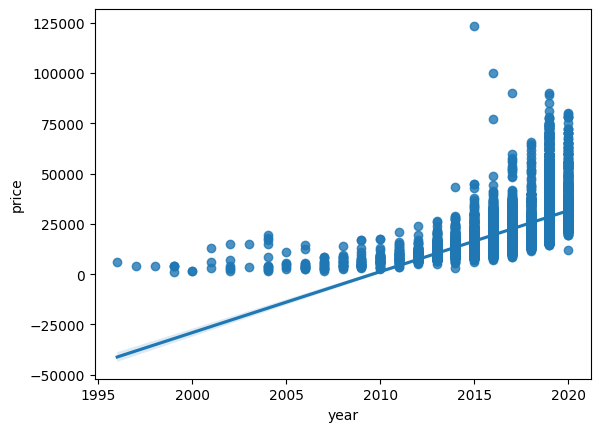

In [4]:
# Regression plot for price and year

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt



sns.regplot(x=df["year"], y=df["price"])

plt.show()

**Reflection:** 

We can see the positive linear relationship between price and year.

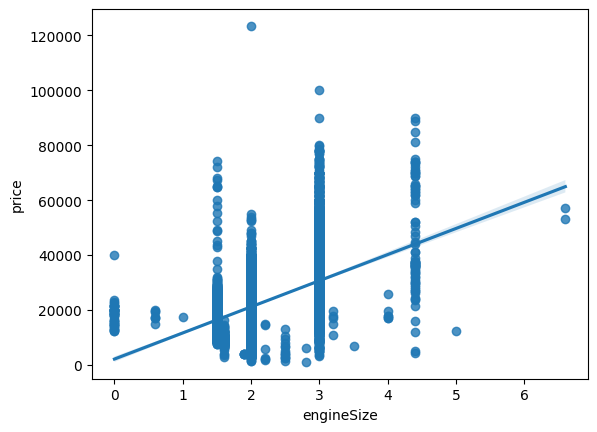

In [6]:
# Regression plot for price and engine size

sns.regplot(x=df["engineSize"], y=df["price"])

plt.show()

**Reflection:**

We can see the positive linear relationship between price and engine size. 

**Let's look at a boxplot of some of the categorical variables compared to price.** 

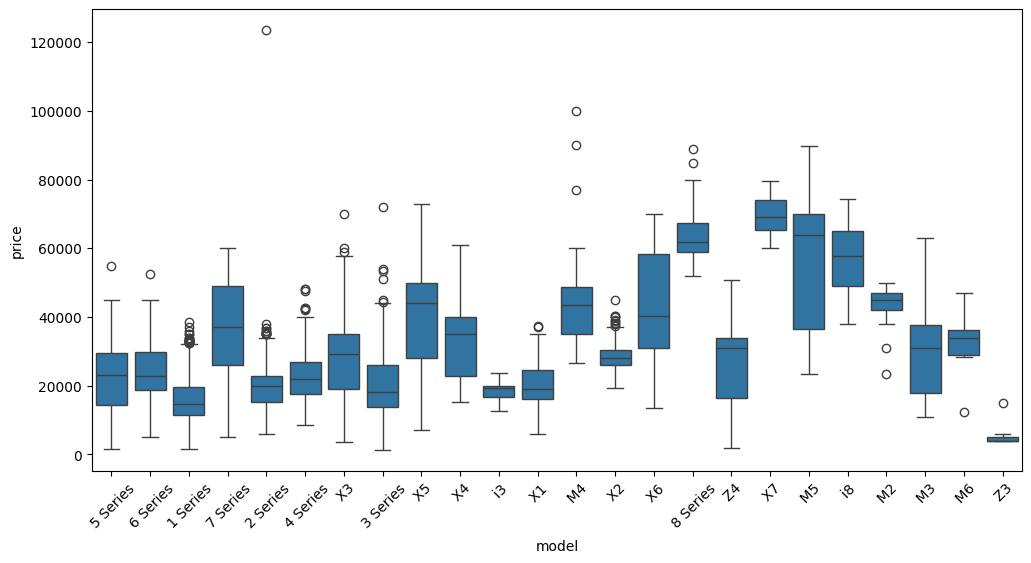

In [5]:
# Boxplot of price and model

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))

sns.boxplot(x=df["model"], y=df["price"])

plt.xticks(rotation=45)

plt.show()

In [6]:
# Count of outliers for model
x_outliers = df["model"]
y_outliers = df["price"]

groups = df.groupby("model")["price"]

q1 = groups.quantile(0.25)
q3 = groups.quantile(0.75)
iqr = q3 - q1

lower = q1 - 1.5 * iqr
upper = q3 + 1.5 * iqr

lower = lower.reindex(x_outliers).values
upper = upper.reindex(x_outliers).values

outliers = (y_outliers < lower) | (y_outliers > upper)

print(outliers.sum())

70


**Reflection:**

We can see the data distribution (quartiles, median, min, max) of the different models of BMW relative to price. We can also see outliers.  

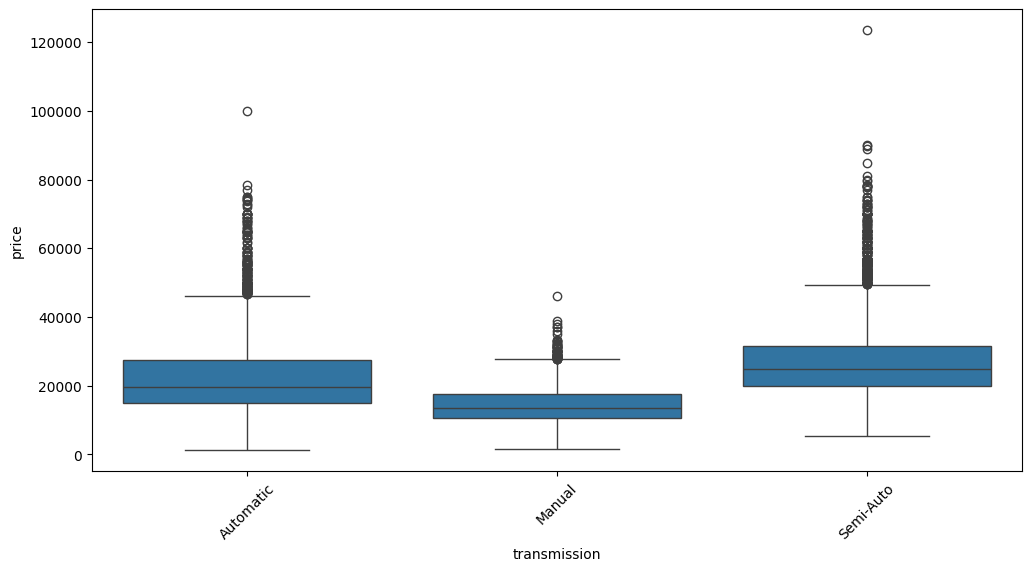

In [7]:
# Boxplot of price and transmission

plt.figure(figsize=(12,6))

sns.boxplot(x=df["transmission"], y=df["price"])

plt.xticks(rotation=45)

plt.show()

In [8]:
# Count of outliers for transmission
x_outliers2 = df["transmission"]
y_outliers2 = df["price"]

groups = df.groupby("transmission")["price"]

q1 = groups.quantile(0.25)
q3 = groups.quantile(0.75)
iqr = q3 - q1

lower = q1 - 1.5 * iqr
upper = q3 + 1.5 * iqr

lower = lower.reindex(x_outliers2).values
upper = upper.reindex(x_outliers2).values

outliers = (y_outliers2 < lower) | (y_outliers2 > upper)

print(outliers.sum())

500


**Reflection:**

We can see the data distribution (quartiles, median, min, max) of the different transmission types relative to price. We can also see outliers. 

**Let's count the number of unique values for each transmission type, model, and engine size.**

In [9]:
# Count of unique values for transmission 

import pandas as pd

counts = df["transmission"].value_counts()

print(counts)
print('-------------------------------------')

# Count of unique values for model

counts = df["model"].value_counts()

print(counts)
print('-------------------------------------')

#Count of unique values for engine size

counts = df["engineSize"].value_counts()

print(counts)
print('-------------------------------------')

transmission
Semi-Auto    4666
Automatic    3588
Manual       2527
Name: count, dtype: int64
-------------------------------------
model
3 Series    2443
1 Series    1969
2 Series    1229
5 Series    1056
4 Series     995
X1           804
X3           551
X5           468
X2           288
X4           179
M4           125
6 Series     108
Z4           108
7 Series     106
X6           106
X7            55
i3            43
8 Series      39
M5            29
M3            27
M2            21
i8            17
M6             8
Z3             7
Name: count, dtype: int64
-------------------------------------
engineSize
2.0    6575
3.0    2458
1.5    1463
1.6     109
4.4      79
0.0      47
2.5      14
0.6       7
2.2       6
4.0       6
3.2       5
1.9       5
6.6       2
2.8       2
1.0       1
5.0       1
3.5       1
Name: count, dtype: int64
-------------------------------------


**Reflection:**

We can see that the transmission Semi-Automatic has the highest count of unique values, the 3 Series model has the highest count of unique values, and the 2.0 engine size has the highest count of unique values. We also see that the transmission types are more even in value counts compared to engine size and model. 

**Let's now look at the distribution of some of the numeric variables as well as categorical variables.**

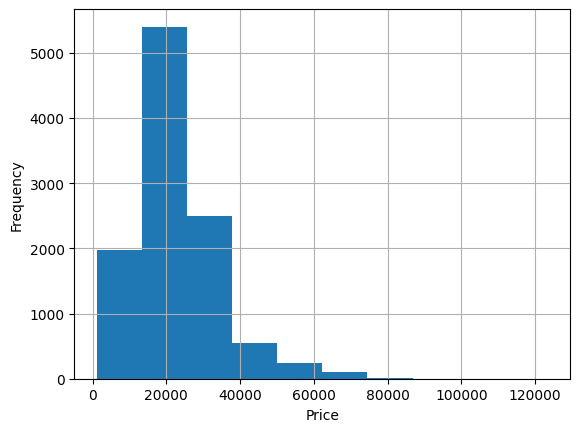

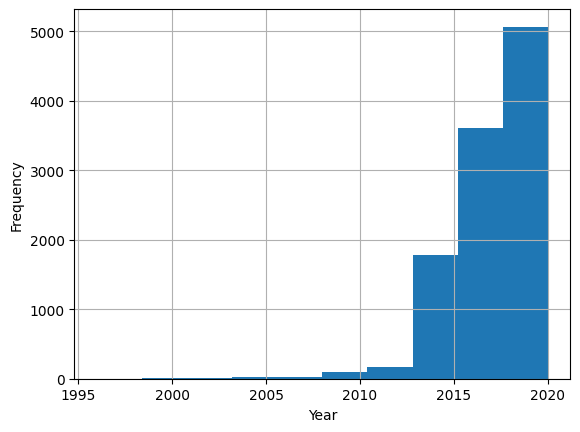

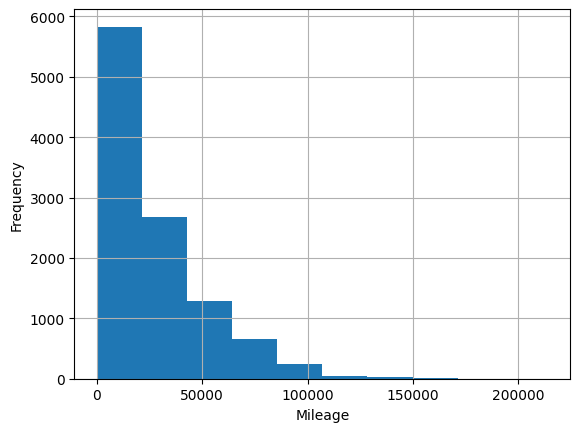

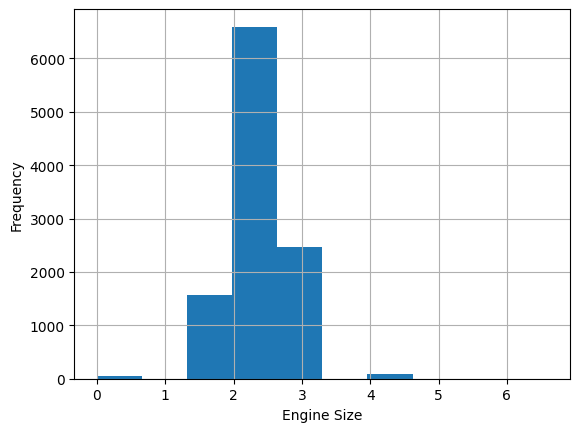

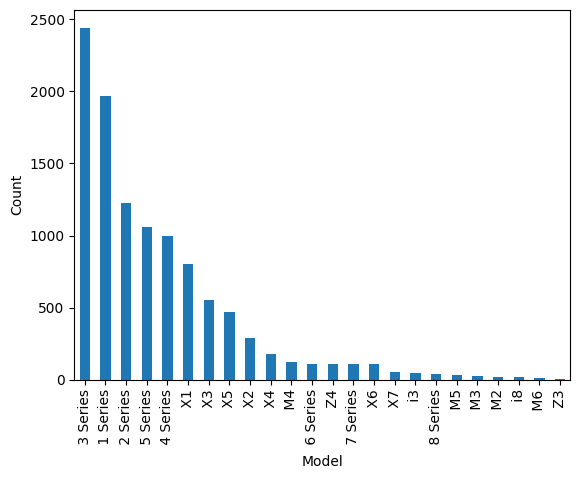

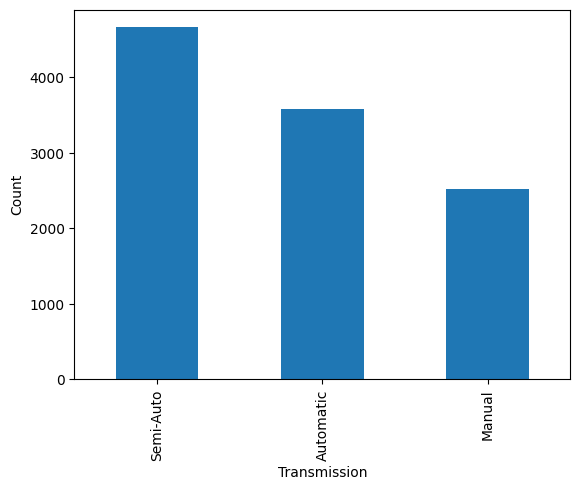

In [11]:
# Histogram of Price

import pandas as pd
import matplotlib.pyplot as plt

df["price"].hist()

plt.xlabel("Price")
plt.ylabel("Frequency")

plt.show()

# Histogram of Year
df["year"].hist()

plt.xlabel("Year")
plt.ylabel("Frequency")
plt.show()

# Histogram of mileage
df["mileage"].hist()

plt.xlabel("Mileage")
plt.ylabel("Frequency")
plt.show()

# Histogram of engine size
df["engineSize"].hist()

plt.xlabel("Engine Size")
plt.ylabel("Frequency")
plt.show()

# Bar chart of model
counts = df["model"].value_counts()

counts.plot(kind="bar")

plt.xlabel("Model")
plt.ylabel("Count")

plt.show()

# Bar chart of transmission
counts = df["transmission"].value_counts()

counts.plot(kind="bar")

plt.xlabel("Transmission")
plt.ylabel("Count")

plt.show()

**Reflection:**

We can see the distribution of the number of different priced vehicles, the number of different type of years each vehicle was manufactured, the number of different vehicles with their respective mileages, as well as the number of different vehicles with their relative engine size. We can also see the count of the different types of models and different types of transmissions. 

**Conclusion Of EDA:**

This concludes are Exploratory Data Analysis (EDA) section. To recap, we have looked at statistical summaries, correlations, regression plots, boxplots, and unqiue values. Through this, we have been able to see relationships between source variables such as year and engine size relative to the price variable. We have been able to see the data distribution of categorical variables like transmission and model. We have counted the unique values of the transmission column, model column, and engine size column. We have also looked at the distribution of numeric and categorical variables through histograms and bar charts. 

**Modeling:**

Let us now move on to modeling analysis. For this, we will do a comparative analysis of three regression models (Linear, Polynomial, and Ridge Regression). Our target variable will be price and our predictive variables will be year, engine size, and model. 

In [37]:
# Linear Regression Model (Single-Variable) (Price = Target Variable. Year = Predictive Variable)
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import numpy as np

X = df[["year"]]
y = df["price"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

model = LinearRegression()

model.fit(X_train, y_train)

pred = model.predict(X_test)

r2 = r2_score(y_test, pred)

rmse = np.sqrt(mean_squared_error(y_test, pred))

mae = mean_absolute_error(y_test, pred)

print("R2:", r2)
print("RMSE:", rmse)
print("MAE:", mae)

R2: 0.3980437579983932
RMSE: 8987.056049469888
MAE: 6029.17535865306


In [36]:
# Polynomial Regression Model (Single-Variable) (Price = Target Variable. Year = Predictive Variable)

import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import numpy as np

X = df[["year"]]
y = df["price"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

poly = PolynomialFeatures(degree=2)

X_train_poly = poly.fit_transform(X_train)
X_test_poly = poly.transform(X_test)

model = LinearRegression()

model.fit(X_train_poly, y_train)

pred = model.predict(X_test_poly)

r2 = r2_score(y_test, pred)
rmse = np.sqrt(mean_squared_error(y_test, pred))
mae = mean_absolute_error(y_test, pred)

print("R2:", r2)
print("RMSE:", rmse)
print("MAE:", mae)

R2: 0.464634767094954
RMSE: 8192.382328133444
MAE: 5562.194840896168


In [40]:
# Ridge Regression Model (Single-Variable) (Price = Target Variable. Year = Predictive Variable)

import pandas as pd
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import Ridge
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import numpy as np

X = df[["year"]]  
y = df["price"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

poly = PolynomialFeatures(degree=2)
X_train_poly = poly.fit_transform(X_train)
X_test_poly = poly.transform(X_test)

ridge = Ridge()
params = {"alpha":[0.0001, 0.001, 0.01, 0.1, 1, 10, 100]}

grid = GridSearchCV(ridge, params, cv=5)
grid.fit(X_train_poly, y_train)

pred = grid.predict(X_test_poly)

r2 = r2_score(y_test, pred)
rmse = np.sqrt(mean_squared_error(y_test, pred))
mae = mean_absolute_error(y_test, pred)

print("Best Alpha:", grid.best_params_)
print("R2:", r2)
print("RMSE:", rmse)
print("MAE:", mae)

Best Alpha: {'alpha': 0.001}
R2: 0.4743820902234622
RMSE: 8231.250908227601
MAE: 5569.150056739123


/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/linear_model/_ridge.py:228: LinAlgWarning: An ill-conditioned matrix detected: slice 0 has rcond = 1.5846852455894455e-16.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/linear_model/_ridge.py:228: LinAlgWarning: An ill-conditioned matrix detected: slice 0 has rcond = 1.6710786261355639e-16.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/linear_model/_ridge.py:228: LinAlgWarning: An ill-conditioned matrix detected: slice 0 has rcond = 1.6294841580541876e-16.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/linear_model/_ridge.py:228: LinAlgWarning: An ill-conditioned matrix detected: slice

**Grid Search Reflection:**

I tested the alpha values 0.0001, 0.001, 0.01, 0.1, 1, 10, and 100. The best alpha value was 0.001. I used 5-fold cross validation to check the R-Squared value to confirm which alpha value was best. An alpha value of 0.001 is somewhat small which means the coefficients of the regression equation will be larger and this may contribute to overfitting. Overfitting is when the model memorizes the training data instead of learning the underlying pattern and not generalizing. 

**Reflection:**

We can see from the single-variable regression models that Ridge regression has the best R-Squared value, RMSE value, and MAE value. This means that the model explains 47% of the variance in the price variable according to the R-Squared value. According to the RMSE value, our model's predictions are about 7911 dollars from the actual values. According to the MAE value, the average absolute difference between our predicted values and actual values is about 5368 dollars. However, this alone does not prove that this model is the most reliable compared to the others. Further analysis would need to be done.

**Let us move on to multiple-variable analysis.**

In [52]:
# Linear Regression Model (Multiple-Variable) (Price = Target Variable. Year, Model, and Engine Size = Predictive Variable)
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

X = df[["year","engineSize","model"]]
y = df["price"]

X = pd.get_dummies(X, columns=["model"], drop_first=True)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

model = LinearRegression()
model.fit(X_train, y_train)

pred = model.predict(X_test)

r2 = r2_score(y_test, pred)
rmse = np.sqrt(mean_squared_error(y_test, pred))
mae = mean_absolute_error(y_test, pred)

print("R2:", r2)
print("RMSE:", rmse)
print("MAE:", mae)

R2: 0.81972920337764
RMSE: 4963.884880428587
MAE: 3259.645326443833


In [49]:
# Polynomial Regression Model (Multiple-Variable) (Price = Target Variable. Year, Model, and Engine Size = Predictive Variable)

import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error


X_num = df[["year","engineSize"]]
X_cat = pd.get_dummies(df["model"], drop_first=True)
y = df["price"]

X_train_num, X_test_num, y_train, y_test = train_test_split(X_num, y, test_size=0.2)
X_train_cat, X_test_cat = X_cat.iloc[X_train_num.index], X_cat.iloc[X_test_num.index]

poly = PolynomialFeatures(degree=2)
X_train_poly = poly.fit_transform(X_train_num)
X_test_poly = poly.transform(X_test_num)

import numpy as np
X_train_final = np.hstack([X_train_poly, X_train_cat.values])
X_test_final = np.hstack([X_test_poly, X_test_cat.values])

model = LinearRegression()
model.fit(X_train_final, y_train)

pred = model.predict(X_test_final)

r2 = r2_score(y_test, pred)
rmse = np.sqrt(mean_squared_error(y_test, pred))
mae = mean_absolute_error(y_test, pred)

print("R2:", r2)
print("RMSE:", rmse)
print("MAE:", mae)

R2: 0.8895027419977283
RMSE: 3677.0301857530735
MAE: 2744.44861408351


In [51]:
# Ridge Regression Model (Multiple-Variable) (Price = Target Variable. Year, Model, and Engine Size = Predictive Variable)

import pandas as pd
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import Ridge
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import numpy as np


X_num = df[["year","engineSize"]]
X_cat = pd.get_dummies(df["model"], drop_first=True)
y = df["price"]

X_train_num, X_test_num, y_train, y_test = train_test_split(X_num, y, test_size=0.2)
X_train_cat, X_test_cat = X_cat.iloc[X_train_num.index], X_cat.iloc[X_test_num.index]

poly = PolynomialFeatures(degree=2)
X_train_poly = poly.fit_transform(X_train_num)
X_test_poly = poly.transform(X_test_num)

X_train_final = np.hstack([X_train_poly, X_train_cat.values])
X_test_final = np.hstack([X_test_poly, X_test_cat.values])

ridge = Ridge()
params = {"alpha":[0.01,0.1,1,10,100]}

grid = GridSearchCV(ridge, params, cv=5)
grid.fit(X_train_final, y_train)

pred = grid.predict(X_test_final)

r2 = r2_score(y_test, pred)
rmse = np.sqrt(mean_squared_error(y_test, pred))
mae = mean_absolute_error(y_test, pred)

print("Best Alpha:", grid.best_params_)
print("R2:", r2)
print("RMSE:", rmse)
print("MAE:", mae)

Best Alpha: {'alpha': 0.01}
R2: 0.8437154394189306
RMSE: 4543.3737371368725
MAE: 2923.8788741998337


**Grid Search Reflection:**

I tested the alpha values 0.0001, 0.001, 0.01, 0.1, 1, 10, and 100. The best alpha value was 0.01. I used 5-fold cross validation to check the R-Squared value to confirm which alpha value was best. An alpha value of 0.01 is somewhat small which means the coefficients of the regression equation will be larger and this may contribute to overfitting. Overfitting is when the model memorizes the training data instead of learning the underlying pattern and not generalizing. 

**Reflection:**

We can see from the multiple-variable regression models that Polynomial regression has the best R-Squared value, RMSE value, and MAE value. This means that the model explains about 88% of the variance in the price variable according to the R-Squared value. According to the RMSE value, our model's predictions are about 3677 dollars from the actual values. According to the MAE value, the average absolute difference between our predicted values and actual values is about 2744 dollars. 

However, this performance doesn't necessarily indicate that the model has the best generalization of the data compared to linear regression and/or ridge regression. The polynomial regression model may be overfitting the training data and not actually learning the underlying pattern (generalizing). This means the model may not perform very well on unseen data. Ridge regression, along with our grid search, may still be the best model to use because it penalizes large coefficients (which contributes to overfitting) and thus makes the model more reliable for generalizing. Further analysis would be needed to confirm this. 

**Conclusion:**

After our analysis of this dataset, we now have showed the necessary code to clean and preprocess the dataset, explore the dataset's statistical summary, concise summary, information about features, correlations, regression plots, boxplots, histograms, bar charts, outliers, unique value counts, etc. We have also looked at multiple regression models on both single-variable and multiple-variables. This has included linear regression, polynomial regression, and ridge regression with grid search hyper parameter tuning. I also calculated the performance metrics of R-Squared, RMSE (Root Mean Squared Error), and MAE (Mean Absolute Error). The models that performed the best based on these metrics were the ridge regression model for the single-variable analysis and the polynomial regression model for the multiple-variable analysis. However, it is worth noting that to be more confident in choosing a model for predictions, we would have to do further analysis. 

With that being said, this concludes my analysis. I would like to thank you for reading through my BMW dataset analysis. 